# ENVRI HUB library usage
In this notebook we'll showcase the intended usage of the *VRE-Lib* component developed by WP 13 and WP 14.
The VRE-Lib is available as a *Python package* on the [public package index](https://pypi.org/project/envrihub/) un the *envrihub* name.
This means it can be installed with:

In [1]:
! pip install --upgrade envrihub
! pip install openapi-spec-validator

  Attempting uninstall: envrihub
    Found existing installation: envrihub 0.1.3
    Uninstalling envrihub-0.1.3:
      Successfully uninstalled envrihub-0.1.3

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


The main element you have to import is the _Hub_ object:

In [2]:
from envrihub import Hub

hub = Hub()

## Free text search
The _Hub_ object offers several search and filter features, exactly like in the Catalogue of Services graphical interface. You can query it with a free text search (that checks all the metadata descriptions in the CoS):

In [3]:
for res in hub.search_catalogue('sealevel'):
    print(res.title)
    print(f'\t resource id: {res.uid}')
    print(f'\t resource type: {res.type}')
    print(f'\t resurce description: {res.description}\n\n')

EPOS - IOC Sealevel Monitoring Station List (as OGC WMS layer)
	 resource id: file:///sealevels_dist_stations_wms
	 resource type: WEB_SERVICE
	 resurce description: This WMS layer allows adding the the station-list into OGC compliant GIS tools. The list of dataproviders can be found on http://www.ioc-sealevelmonitoring.org.<br><br>This service is adopted from the EPOS Platform (https://www.ics-c.epos-eu.org) and provided to the ENVRI Hub by EPOS ERIC.




The `search_catalogue` method always return a *Generator* object, i.e. somthing you can iterate on, so you can process search results one by one as they get fetched from the catalogue.

Each result has the shape of a `Distribution` object, containing anything you need to work with that resource, including the data access logic. We'll see that in the detail later, for now it's enough to know that all of them have an `id` that is unique in the Catalogue and there are two types of them: *Web Services*, and *Downloadable Files*.
## Spatial coverage search
We can query the catalogue also by specifying a region of interest. Such a region can be expressed as a WKT string, a format used by most GIS applications, so you can copy-paste spatial information from your GIS of choice and shove it straight into the `search_catalogue` function.

In [4]:
import logging
logger = logging.getLogger()
logger.setLevel(logging.CRITICAL)

geography = 'POLYGON((10.70 48.34,18.98 48.34, 18.98 42.17, 10.70 42.17, 10.70 48.34))'

for res in hub.search_catalogue(geography = geography):
    print(res.title)
    print(f'\t resource id: {res.uid}')
    print(f'\t resource type: {res.type}')
    print(f'\t resurce description: {res.description}\n\n')
    

AphiaRecordsByAphiaIDs
	 resource id: https://doi.org/10.14284/wormswebservice_distRecByAphiaIds
	 resource type: WEB_SERVICE
	 resurce description: The World Register of Marine Species (WoRMS) is a species information backbone, providing an authoritative classification and catalogue of names of marine organisms. WoRMS contains the names, synonyms, and vernacular names, as well as references, images, biogeographic data, distributions, and traits, where those information are available. The information in WoRMS is curated and maintained at VLIZ, and a number of services to query for information in WoRMS are provided via its website (https://www.marinespecies.org/). The data system behind WoRMS is called Aphia. All the names in WoRMS are tagged with an unique and persistent ID: the AphiaID. Using the WoRMS RESTful services, one can obtain the information held in Aphia using the AphiaID as key, or using the names, external identifiers, classification and trait keywords, etc. The service Ap

## EXV and temporal coverage
We can think of other kinds of facets, like time boundaries, or specific variables of intersest.
The `exv` field accepts as value any of the [known EXVs](https://catalogue.staging.envri.eu/api/v1/resources/exvs) in the ENVRI-Hub catalogue 

In [5]:
for res in hub.search_catalogue(exv = "https://vocab.nerc.ac.uk/collection/EXV/current/EXV028/",
                               start_date = '2024-01-01', end_date = '2025-01-01'):
    print(res.title)
    print(f'\t resource id: {res.uid}')
    print(f'\t resource type: {res.type}')
    print(f'\t resurce description: {res.description}\n\n')

Argo - EXV28 - DOXY
	 resource id: file:///ArgoBGC_distribution_004
	 resource type: WEB_SERVICE
	 resurce description: ERDDAP data access service to Argo Float ocean dissolved oxygen. The service is parameterized so that only data with good values and good spatio-temporal coordinates are collected and shown on the map. Dissolved oxygen parameter corresponds to https://vocab.nerc.ac.uk/collection/EXV/current/EXV028 (The EXV table is a programming implementation of Essential Variables including GCOS-defined Essential Climate Variables - https://gcos.wmo.int/site/global-climate-observing-system-gcos/essential-climate-variables/ - and of GOOS-defined Essential Ocean Variables - https://goosocean.org/what-we-do/framework/essential-ocean-variables/).


Argo data access API
	 resource id: file:///software/notebook/1107/Dataset/001/argo78/Distribution/001
	 resource type: DOWNLOADABLE_FILE
	 resurce description: In this notebook, we show how to invoke a simple argo data access service hosted 

# Accessing data
Now let's talk about *data access*. Remember the `Distribution` object? It contains all you need to access data and to work with it, and you can get one either by *searching* the catalogue as we saw above, or by retrieving one directly using its `uid`, like in the following example.

In [6]:
service_id = 'file:///ArgoBGC_distribution_005'

res = hub.fetch_from_catalogue(service_id)
print(res.title)

Argo - EXV33 - CHLA - GeoJSON


Where do you get IDs? Either browsing the catlogue on your own, or with the `search_catalogue` method.

What we have now inside the `res` variable is a `Distribution` object that has the following attributes:
+ `title`: the resource title/display name
+ `uid`: the unique internal identifier to fetch it a later time
+ `description`: a human readable minimal description
+ `type`: whether it is a web service or a file
+ `href`: a link to more metadata
+ `service_documentation`: a link to some material that should allow you to get a hold on how to use the resouce.
+ `metadata`: all the metadata avaiable.

Plus the `is_downloadable` function that answers the fundamental question for all you digital kleptomaniacs: *can I download it on my laptop?*

In [7]:
res.metadata

{'DOI': ['10.17882/42182'],
 'availableFormats': [{'format': 'application/epos.geo+json',
   'href': 'https://catalogue.envri.eu/api/v1/execute/dbd0e8e3-0a97-4c1a-ad08-58d96546e4ec?format=application/geo+json',
   'label': 'GEOJSON',
   'originalFormat': 'application/geo+json',
   'type': 'ORIGINAL'}],
 'categories': {'children': [{'children': [{'ddss': 'category:ENVRI_conc',
      'name': 'Services'}],
    'code': 'ENVRIServices',
    'color': '#A5EBA9',
    'id': '1',
    'imgUrl': 'https://gitlab.a.incd.pt/envri-hub-next/cos-icons/-/raw/main/services.png',
    'linkUrl': '',
    'name': 'Services'}],
  'name': 'domains'},
 'dataProvider': [{'country': 'FR',
   'dataProviderLegalName': 'Euro-Argo ERIC',
   'dataProviderUrl': 'https://www.euro-argo.eu/',
   'instanceid': 'ded6fbf2-d357-49fc-951d-a0c4599e7826',
   'metaid': 'ded6fbf2-d357-49fc-951d-a0c4599e7826',
   'uid': 'ded6fbf2-d357-49fc-951d-a0c4599e7826'}],
 'description': 'ERDDAP data access service to Argo Float ocean chorophy

Quite some information isn't it?
That's becasue you might want to know what you'll find inside the data *before* opening it. You know... To avoid jumpscares.

Now it's finally time to access the *actual data* with the `dao` attribute, that *always* comes with helpful documentation you can access with the *help()* function or with third party Jupyter extensions.

In [8]:
catalogue_dao = res.dao
help(catalogue_dao)

Help on ArgoEXV33CHLAviaERDDAP in module abc object:

class ArgoEXV33CHLAviaERDDAP(envrihub.data_access.argo.ArgoERDDAPDao)
 |  Method resolution order:
 |      ArgoEXV33CHLAviaERDDAP
 |      envrihub.data_access.argo.ArgoERDDAPDao
 |      envrihub.data_access.models.DataAccessObject
 |      ABC
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  access(
 |      self,
 |      /,
 |      *,
 |      latitude_greater='29',
 |      longitude_less='30',
 |      longitude_greater='-21',
 |      pres_less='10',
 |      time_less='2025-02-01T00:00:00Z',
 |      pres_greater='0',
 |      time_greater='2025-01-01T00:00:00Z',
 |      latitude_less='66',
 |      additional_headers: dict = None
 |  ) from envrihub.data_access.catalogue_metadata_client.build_access_function.<locals>
 |      ERDDAP data access service to Argo Float ocean chorophyll-a. The service is parameterized so that only data with good values and good spatio-temporal coordinates are collected and shown on the map. Chloro

And now let's do some magic with data. The [Environmental Expert](https://chat.envri.eu/) can help you with this.

In [9]:
import pandas as pd
import json

service_response = catalogue_dao.access(latitude_less='33', latitude_more='29', longitude_less='30', longitude_more='-21', pres_less='10', time_less='2025-02-01T00:00:00Z', pres_more='0', time_more='2025-01-01T00:00:00Z')

# 1. The service returns a geoJSON, let's load it
data = json.loads(service_response)

# 2. Extract features
features = data['features']

# 3. Transform 'properties' into dictionaries

rows = []
for f in features:
    # Get all properties (temp, pres, psal, ecc.)
    record = f['properties'].copy()
    
    # Extract coordinates: [longitudine, latitudine]
    record['longitude'] = f['geometry']['coordinates'][0]
    record['latitude'] = f['geometry']['coordinates'][1]
    
    rows.append(record)

# 4. Create DataFrame
df = pd.DataFrame(rows)

# 5. Remove empty column
df = df.replace("", float('nan'))
df_pulito = df.dropna(axis=1, how='all')

# Print result
print(f"Clean table: {df_pulito.shape[0]} rows and {df_pulito.shape[1]} columns.")
print(df_pulito.head())

Clean table: 47 rows and 36 columns.
  wmo_inst_type               data_type           date_update        pi_name  \
0           841  Argo synthetic profile  2026-03-12T15:14:14Z  Miguel SANTOS   
1           841  Argo synthetic profile  2026-03-12T15:14:14Z  Miguel SANTOS   
2           841  Argo synthetic profile  2026-03-12T15:14:14Z  Miguel SANTOS   
3           841  Argo synthetic profile  2026-03-12T15:14:14Z  Miguel SANTOS   
4           841  Argo synthetic profile  2026-03-12T15:14:14Z  Miguel SANTOS   

        doxy doxy_qc  doxy_adjusted doxy_adjusted_qc  doxy_adjusted_error  \
0  201.04784       3      218.76015                1            10.908089   
1  201.05670       3      218.76980                1            10.906965   
2  201.07594       3      218.79074                1            10.905861   
3        NaN                    NaN                                   NaN   
4  201.10391       3      218.82117                1            10.904591   

   pres  ... platfo

More magic: let's draw a graph

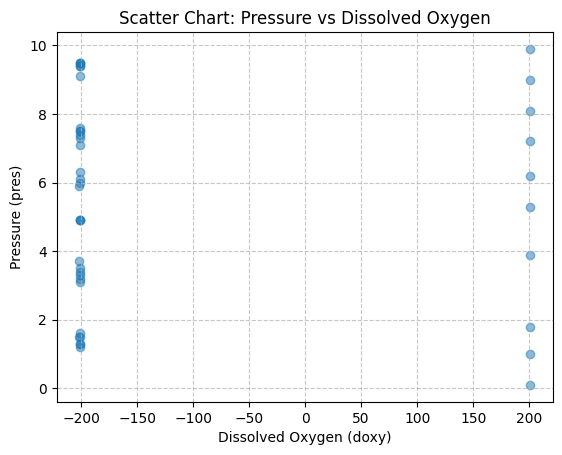

In [10]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load data
with open('dati_servizio.bin', 'r') as f:
    data = json.load(f)

# Extract properties
features = data['features']
df = pd.DataFrame([f['properties'] for f in features])

# Conversion and clean up
df['pres'] = pd.to_numeric(df['pres'], errors='coerce')
df['doxy'] = pd.to_numeric(df['doxy'], errors='coerce')
df_plot = df.dropna(subset=['pres', 'doxy'])

# Create Scatter Chart
plt.scatter(df_plot['doxy'], df_plot['pres'], alpha=0.5)
plt.xlabel('Dissolved Oxygen (doxy)')
plt.ylabel('Pressure (pres)')
plt.title('Scatter Chart: Pressure vs Dissolved Oxygen')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('scatter_pres_doxy.png')